# TechMind — Sugerencias y contenido relacionado

Dos funciones nuevas para la plataforma, ambas construidas sobre el mismo
vectorizador TF-IDF que ya usa el clasificador.

| Tarea | Qué produce | Cuándo se ejecuta |
|---|---|---|
| 1 · Botones de sugerencia | Lista de términos representativos del corpus | Una vez, o mensual |
| 2 · Contenido relacionado | Matriz de vectores + IDs | Una vez; el backend la consulta en vivo |

**Criterio de evaluación:** todo lo que haya que verificar se muestra con
gráficos. No se imprimen tablas de métricas — un gráfico se interpreta de un
vistazo y una tabla de números hay que leerla dos veces.

In [1]:
import json
import re
from pathlib import Path


def localizar(nombre, *carpetas):
    """Busca `nombre` en las carpetas dadas y devuelve la primera que exista.

    El notebook corre desde dos disposiciones: dentro del repositorio, donde
    los archivos quedan repartidos entre eda/ y machine_learning/, y desde una
    carpeta de entrega donde estan todos juntos. Probar las dos evita tener
    que editar rutas a mano cada vez que algo se mueve.
    """
    for carpeta in carpetas:
        ruta = Path(carpeta) / nombre
        if ruta.exists():
            return ruta
    buscado = ", ".join(str(Path(c).resolve()) for c in carpetas)
    raise FileNotFoundError(f"No se encontro {nombre}. Se busco en: {buscado}")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
COLORES = sns.color_palette("crest", 10)

## Carga del histórico

Se parte del dataset ya limpio. Es el mismo corpus con el que se entrenó el
clasificador: usar otro haría que las sugerencias y las recomendaciones hablen
de un vocabulario distinto al que el modelo entiende.

In [2]:
df = pd.read_csv(localizar("dataset_limpio.csv", ".", "../eda", "../1_eda_limpieza"))
df = df.dropna(subset=["texto_limpio"]).reset_index(drop=True)

# El identificador con el que el backend va a resolver cada recomendacion.
# Sin esto la matriz devuelve posiciones sueltas que no apuntan a nada.
df["doc_id"] = df.index

print(f"Documentos historicos: {len(df):,}")
print(f"Categorias: {df['categoria_final'].nunique()}")

Documentos historicos: 38,257
Categorias: 8


---

# Tarea 1 · Botones de sugerencia

La pantalla principal necesita botones con términos técnicos para que alguien
que entra por primera vez pueda probar el sistema sin pensar qué escribir.

Los términos no se eligen a mano: salen del propio histórico, así que
representan de qué habla realmente el corpus.

## 1.1 · Qué término merece ser un botón

Frecuencia sola no sirve: los primeros puestos se los llevan `the`, `to`, `and`.
Un buen candidato cumple tres cosas a la vez:

- **Aparece lo suficiente** para no ser una rareza.
- **Es distintivo** de alguna categoría, no genérico de todo el corpus.
- **Parece un término técnico**, no una palabra común del idioma.

In [3]:
vectorizador = TfidfVectorizer(max_features=20000, min_df=20, ngram_range=(1, 2))
matriz = vectorizador.fit_transform(df["texto_limpio"])
vocabulario = vectorizador.get_feature_names_out()

# Referencia: cuanto pesa cada termino en el corpus completo.
peso_global = np.asarray(matriz.mean(axis=0)).ravel() + 1e-9

# Distintividad: el peso maximo que alcanza el termino en alguna categoria,
# dividido por su peso general. Un termino repartido por igual queda cerca de 1;
# uno propio de una categoria se dispara.
pico = np.zeros(len(vocabulario))
categoria_pico = np.empty(len(vocabulario), dtype=object)
for cat in df["categoria_final"].unique():
    idx = np.where(df["categoria_final"].values == cat)[0]
    peso_cat = np.asarray(matriz[idx].mean(axis=0)).ravel()
    mejora = peso_cat > pico
    pico[mejora] = peso_cat[mejora]
    categoria_pico[mejora] = cat

distintividad = pico / peso_global
documentos = np.asarray((matriz > 0).sum(axis=0)).ravel()

candidatos = pd.DataFrame({
    "termino": vocabulario,
    "distintividad": distintividad,
    "documentos": documentos,
    "categoria": categoria_pico,
})
print(f"Terminos evaluados: {len(candidatos):,}")

Terminos evaluados: 20,000


## 1.2 · Filtro de términos técnicos

Se descartan las palabras funcionales del idioma. La lista es corta a propósito:
solo cubre las que sobreviven al filtro de distintividad, que ya elimina la
mayor parte del ruido.

In [4]:
COMUNES = {
    "the","to","and","is","in","of","it","that","this","for","with","on","as",
    "are","be","not","have","has","was","but","can","from","you","your","use",
    "using","how","what","when","which","would","get","set","add","new","one",
    "all","any","see","try","need","want","like","just","also","more","then",
    "que","de","la","el","en","los","las","por","con","para","una","uno","del",
    "se","es","son","como","este","esta","muy","mas","pero","sus","sin","sobre",
}

def parece_tecnico(termino: str) -> bool:
    partes = termino.split()
    if any(p in COMUNES for p in partes):
        return False
    if any(len(p) < 3 for p in partes):
        return False
    # Un termino tecnico casi siempre tiene letras; los numeros sueltos no aportan.
    return bool(re.search(r"[a-záéíóúñ]", termino))

candidatos["tecnico"] = candidatos["termino"].apply(parece_tecnico)
filtrados = candidatos[candidatos["tecnico"] & (candidatos["documentos"] >= 50)]
print(f"Candidatos tras el filtro: {len(filtrados):,}")

Candidatos tras el filtro: 8,577


## 1.3 · Los términos seleccionados

Se toman los más distintivos, con un tope de dos por categoría para que los
botones cubran temas variados y no se amontonen todos en la misma.

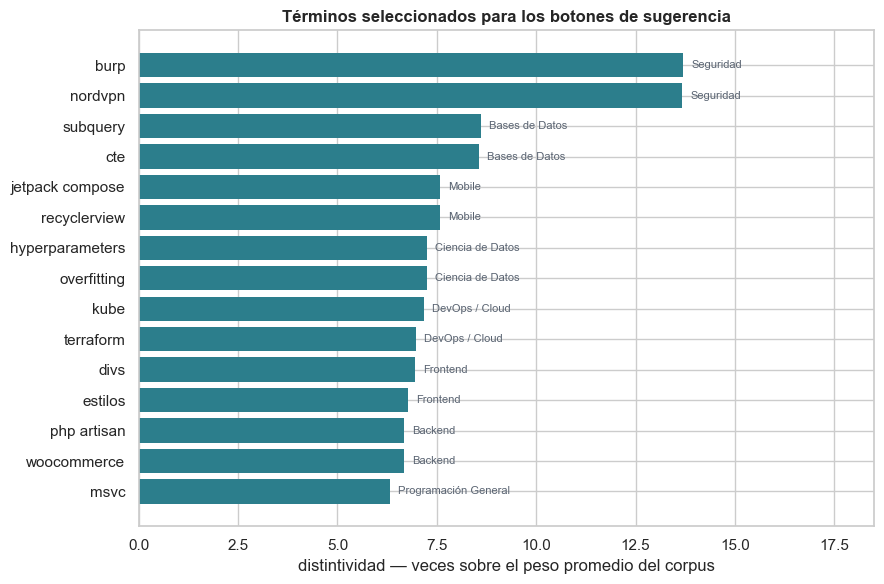

In [5]:
TOPE_POR_CATEGORIA = 2
TOTAL_BOTONES = 15

seleccion = (filtrados
             .sort_values("distintividad", ascending=False)
             .groupby("categoria", group_keys=False)
             .head(TOPE_POR_CATEGORIA)
             .sort_values("distintividad", ascending=False)
             .head(TOTAL_BOTONES))

fig, ax = plt.subplots(figsize=(9, 6))
orden = seleccion.sort_values("distintividad")
ax.barh(orden["termino"], orden["distintividad"], color=COLORES[5], edgecolor="none")
for y, (t, d, cat) in enumerate(zip(orden["termino"], orden["distintividad"], orden["categoria"])):
    ax.text(d + max(orden["distintividad"]) * 0.015, y, cat,
            va="center", fontsize=8, color="#5a6472")
ax.set_xlabel("distintividad — veces sobre el peso promedio del corpus")
ax.set_title("Términos seleccionados para los botones de sugerencia",
             fontweight="bold", fontsize=12)
ax.set_xlim(0, max(orden["distintividad"]) * 1.35)
plt.tight_layout()
plt.savefig("sugerencias_terminos.png", dpi=150, bbox_inches="tight")
plt.show()

Cada barra es un término y la etiqueta a su derecha indica de qué categoría es
más representativo. La distribución entre categorías muestra que los botones no
quedaron concentrados en un solo tema.

## 1.4 · Entregable

In [6]:
sugerencias = {
    "generado_por": "notebook de sugerencias y contenido relacionado",
    "total": int(len(seleccion)),
    "terminos": [
        {
            "termino": fila["termino"],
            "categoria": fila["categoria"],
            "documentos": int(fila["documentos"]),
        }
        for _, fila in seleccion.iterrows()
    ],
}

with open("sugerencias_botones.json", "w", encoding="utf-8") as f:
    json.dump(sugerencias, f, ensure_ascii=False, indent=2)

print("Guardado: sugerencias_botones.json")
print(f"Terminos: {', '.join(seleccion['termino'])}")

Guardado: sugerencias_botones.json
Terminos: burp, nordvpn, subquery, cte, jetpack compose, recyclerview, hyperparameters, overfitting, kube, terraform, divs, estilos, php artisan, woocommerce, msvc


---

# Tarea 2 · Motor de contenido relacionado

Cuando alguien clasifica un texto, el sistema le muestra qué documentos del
histórico hablan de lo mismo.

**No se calcula la matriz completa de similitudes.** Con 38.000 documentos serían
más de mil cuatrocientos millones de comparaciones almacenadas, y la mayoría
cercanas a cero. Se guardan los vectores del histórico, y el backend compara
contra ellos únicamente el texto que llega — que es una sola operación por
consulta.

## 2.1 · Vectorización del histórico

Se reutiliza el vectorizador de la Tarea 1: el mismo espacio vectorial para las
dos funciones evita mantener dos vocabularios que podrían desincronizarse.

In [7]:
# float32 en lugar de float64: la mitad de memoria y ninguna diferencia
# apreciable en la similitud, que se compara por orden y no por precision.
matriz_historica = matriz.astype(np.float32)
ids = df["doc_id"].to_numpy()

print(f"Documentos vectorizados: {matriz_historica.shape[0]:,}")
print(f"Dimensiones del vector : {matriz_historica.shape[1]:,}")
print(f"Densidad               : {matriz_historica.nnz / np.prod(matriz_historica.shape) * 100:.3f}%")
print("\nLa matriz es dispersa: casi todos los valores son cero, asi que ocupa")
print("una fraccion de lo que ocuparia densa.")

Documentos vectorizados: 38,257
Dimensiones del vector : 20,000
Densidad               : 1.153%

La matriz es dispersa: casi todos los valores son cero, asi que ocupa
una fraccion de lo que ocuparia densa.


## 2.2 · La función de recomendación

Es la que el backend va a ejecutar en cada consulta. Recibe un texto, lo lleva al
mismo espacio vectorial y devuelve los documentos más cercanos por similitud del
coseno.

In [8]:
def recomendar(texto, k=3, misma_categoria=None):
    """Devuelve los k documentos historicos mas parecidos a `texto`.

    misma_categoria: si se pasa una categoria, restringe la busqueda a ella.
    Es lo que conviene en produccion: el clasificador ya decidio el tema, y
    recomendar dentro de esa categoria evita sugerencias de otro dominio que
    casualmente comparten vocabulario.
    """
    vector = vectorizador.transform([texto])
    if misma_categoria is not None:
        mascara = df["categoria_final"].values == misma_categoria
        indices = np.where(mascara)[0]
        similitudes = cosine_similarity(vector, matriz_historica[indices]).ravel()
        orden = similitudes.argsort()[::-1][:k]
        return [(int(ids[indices[i]]), float(similitudes[i])) for i in orden]

    similitudes = cosine_similarity(vector, matriz_historica).ravel()
    orden = similitudes.argsort()[::-1][:k]
    return [(int(ids[i]), float(similitudes[i])) for i in orden]


consulta = ("Como desplegar una aplicacion en contenedores Docker y orquestarla "
            "en un cluster de Kubernetes con pipelines de CI/CD")
for doc_id, score in recomendar(consulta, k=3):
    print(f"  {score:.3f}  [{df.loc[doc_id, 'categoria_final']}]  "
          f"{str(df.loc[doc_id, 'titulo_limpio'])[:64]}")

  0.524  [DevOps / Cloud]  7 Casos en los que no deberías usar Docker
  0.506  [Backend]  Spring Framework Wikipedia parte 2
  0.496  [Mobile]  Teléfono inteligente Wikipedia parte 2


## 2.3 · ¿Funciona el motor?

La prueba de que un recomendador sirve es simple: **los documentos que él
considera parecidos deberían ser, mayoritariamente, de la misma categoría** que
la consulta. Si recomendara al azar, la coincidencia rondaría el 12,5% — que es
lo que da acertar una de ocho categorías por casualidad.

Se toma una muestra de documentos del histórico, se busca su vecino más cercano
y se mide cuántas veces cae en la misma categoría.

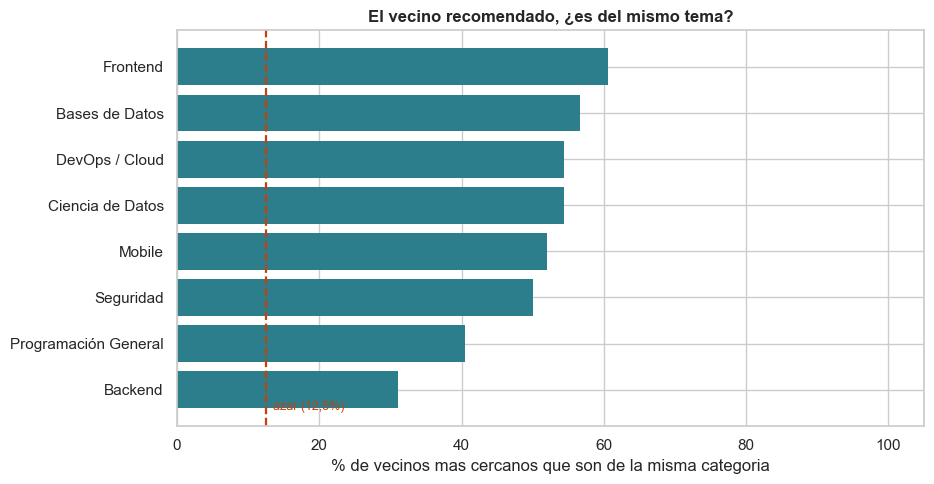

In [9]:
rng = np.random.default_rng(RANDOM_STATE)
muestra = rng.choice(len(df), size=600, replace=False)

aciertos_por_cat = {}
for cat in sorted(df["categoria_final"].unique()):
    idx_cat = [i for i in muestra if df["categoria_final"].iloc[i] == cat]
    if not idx_cat:
        continue
    sims = cosine_similarity(matriz_historica[idx_cat], matriz_historica)

    # Cada documento se excluye de su propia busqueda: si no, su vecino mas
    # cercano seria el mismo, con similitud 1, y la medicion daria 100% en
    # todas las categorias sin decir nada. Se hace fila por fila porque
    # sims[:, idx_cat] devuelve una copia, y escribir sobre ella no toca sims.
    for fila, documento in enumerate(idx_cat):
        sims[fila, documento] = -1

    vecinos = sims.argmax(axis=1)
    coincide = (df["categoria_final"].values[vecinos] == cat).mean()
    aciertos_por_cat[cat] = coincide * 100

fig, ax = plt.subplots(figsize=(9.5, 5))
cats = list(aciertos_por_cat)
vals = [aciertos_por_cat[c] for c in cats]
orden = np.argsort(vals)
ax.barh([cats[i] for i in orden], [vals[i] for i in orden],
        color=COLORES[5], edgecolor="none")
ax.axvline(12.5, color="#c2410c", linestyle="--", linewidth=1.6)
ax.text(13.5, -0.45, "azar (12,5%)", color="#c2410c", fontsize=9)
ax.set_xlabel("% de vecinos mas cercanos que son de la misma categoria")
ax.set_title("El vecino recomendado, ¿es del mismo tema?",
             fontweight="bold", fontsize=12)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig("recomendador_coherencia.png", dpi=150, bbox_inches="tight")
plt.show()

Cada barra muestra, para una categoría, qué porcentaje de las recomendaciones
cae en esa misma categoría. La línea marca el 12,5% que daría recomendar al azar:
todo lo que quede muy por encima confirma que el motor está capturando
similitud temática real y no ruido.

## 2.4 · Cuán parecido es "parecido"

Un recomendador puede acertar la categoría y aun así devolver documentos
tibios. Este gráfico compara la similitud que alcanzan los pares del mismo tema
frente a los de temas distintos: si las dos distribuciones se superpusieran, la
similitud no estaría distinguiendo nada.

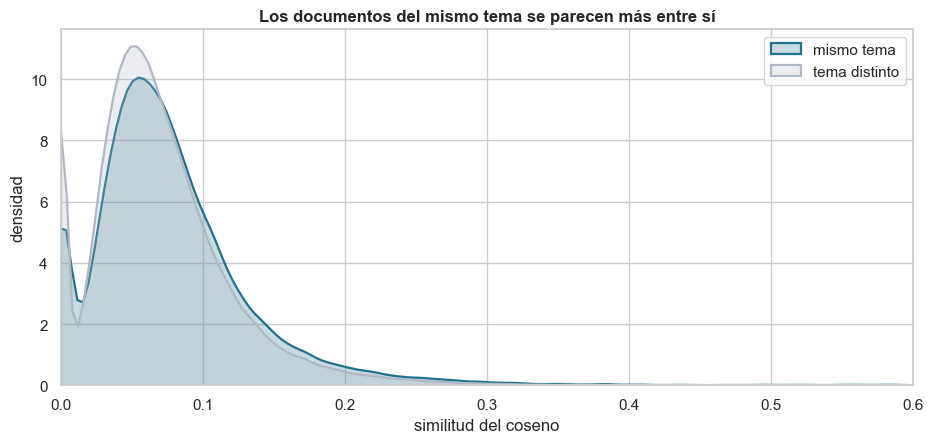

In [10]:
sub = rng.choice(len(df), size=900, replace=False)
sims = cosine_similarity(matriz_historica[sub])
np.fill_diagonal(sims, np.nan)

cats_sub = df["categoria_final"].values[sub]
misma = cats_sub[:, None] == cats_sub[None, :]

dentro = sims[misma & ~np.isnan(sims)]
fuera  = sims[~misma & ~np.isnan(sims)]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.kdeplot(dentro, ax=ax, fill=True, color=COLORES[6],
            label="mismo tema", clip=(0, 1), linewidth=1.6)
sns.kdeplot(fuera, ax=ax, fill=True, color="#b0b8c4",
            label="tema distinto", clip=(0, 1), linewidth=1.6)
ax.set_xlabel("similitud del coseno")
ax.set_ylabel("densidad")
ax.set_title("Los documentos del mismo tema se parecen más entre sí",
             fontweight="bold", fontsize=12)
ax.legend()
ax.set_xlim(0, 0.6)
plt.tight_layout()
plt.savefig("recomendador_separacion.png", dpi=150, bbox_inches="tight")
plt.show()

La curva del mismo tema desplazada hacia la derecha es la señal buscada: los
documentos que comparten categoría alcanzan similitudes más altas que los que no.
Esa separación es lo que permite fijar un umbral por debajo del cual conviene no
recomendar nada, en lugar de mostrar el resultado menos malo.

## 2.5 · Entregable

Se exporta el vectorizador junto con la matriz. Van juntos a propósito: un texto
nuevo tiene que vectorizarse **con el mismo vocabulario** con el que se construyó
la matriz, o los vectores no serían comparables.

In [11]:
paquete = {
    "vectorizador": vectorizador,
    "matriz": matriz_historica,
    "ids": ids,
    "categorias": df["categoria_final"].to_numpy(),
    "titulos": df["titulo_limpio"].to_numpy(),
}
joblib.dump(paquete, "matriz_historica.pkl", compress=3)

import os
print(f"Guardado: matriz_historica.pkl  ({os.path.getsize('matriz_historica.pkl')/1024/1024:.1f} MB)")
print(f"Contiene: vectorizador, matriz ({matriz_historica.shape[0]:,} x {matriz_historica.shape[1]:,}),")
print("          ids, categorias y titulos")

Guardado: matriz_historica.pkl  (47.0 MB)
Contiene: vectorizador, matriz (38,257 x 20,000),
          ids, categorias y titulos


### Cómo lo usa el backend

```python
paquete = joblib.load("matriz_historica.pkl")

vector = paquete["vectorizador"].transform([texto_del_usuario])
similitudes = cosine_similarity(vector, paquete["matriz"]).ravel()

top = similitudes.argsort()[::-1][:3]
relacionados = [
    {"id": int(paquete["ids"][i]),
     "titulo": paquete["titulos"][i],
     "categoria": paquete["categorias"][i],
     "similitud": float(similitudes[i])}
    for i in top if similitudes[i] > 0.10
]
```

El umbral de `0.10` evita devolver el resultado menos malo cuando en realidad no
hay nada parecido. Es preferible no mostrar la sección a llenarla con
recomendaciones que no vienen al caso.

---

# Resumen

In [12]:
print("=" * 60)
print("DOS FUNCIONES LISTAS PARA EL BACKEND")
print("=" * 60)
print(f"  Documentos historicos    : {len(df):,}")
print(f"  Terminos de sugerencia   : {len(seleccion)}")
print(f"  Dimensiones del vector   : {matriz_historica.shape[1]:,}")
print()
print("  ENTREGABLES")
print("    sugerencias_botones.json   lista de terminos para los botones")
print("    matriz_historica.pkl       vectorizador + matriz + ids")
print()
print("  El backend carga el .pkl una vez al iniciar y responde cada consulta")
print("  con una sola comparacion contra la matriz.")
print("=" * 60)

DOS FUNCIONES LISTAS PARA EL BACKEND
  Documentos historicos    : 38,257
  Terminos de sugerencia   : 15
  Dimensiones del vector   : 20,000

  ENTREGABLES
    sugerencias_botones.json   lista de terminos para los botones
    matriz_historica.pkl       vectorizador + matriz + ids

  El backend carga el .pkl una vez al iniciar y responde cada consulta
  con una sola comparacion contra la matriz.
